**照片轉YUV:**



因為照片是三維陣列(H, W, 3)，而每個 (y, x) 就是一個 pixel，所以要將照片轉YUV:

**1.讀入一張實際照片**


---



**2.把影像轉成浮點數**

=>把像素值從 0–255 轉成 0–1（或保留 0–255 也可以）

因:權重是小數，浮點數比較符合數學公式，也比較不會 overflow


---


**3.準備 A 矩陣（權重）**

=>定義老師白板上的 3×3 矩陣

因: A矩陣定義了「RGB 對 Y、U、V 的貢獻比例」

這一步就是在實作數學模型


---



**4.準備 offset（位移）**
=>定義一個常數向量（例如 U、V 加 0.5 或 128）

因: U、V 是色差，本來就可能是負數

實際儲存與壓縮不能有負值


---




**5.建立一個空的 YUV 影像**

=>建一個跟原圖一樣大小的陣列，用來存結果

因:每算完一個 pixel，要有地方放

=>輸出影像

---
**6.用 for 迴圈掃過每一個 pixel**

=>兩層 for：一個掃高度，一個掃寬度

因:明確對應「一個 pixel 一個 pixel 算」，可清楚每個點在做什麼轉換



---


**7.取出該 pixel 的 B、G、R**

=>從影像中取出 (B, G, R)
調整成 (R, G, B)

因:OpenCV 預設是 BGR

=>公式是 RGB


---


**8.計算 Y、U、V（核心）**

=>用 A 矩陣乘上 RGB，再加上 offset

因:這一步就是「RGB → YUV」

也是整個實驗唯一的數學核心


---


**9：把結果存回 YUV 影像**

做什麼

把算好的 Y、U、V 放到對應的位置


因:這樣整張圖才會完整

後面才能顯示或儲存


---


**10：觀察 / 顯示結果**

=>分別看 Y、U、V 通道

因:Y 應該像黑白圖（亮度），U、V 看起來會比較模糊（色彩）

這一步是在「驗證你算對了」



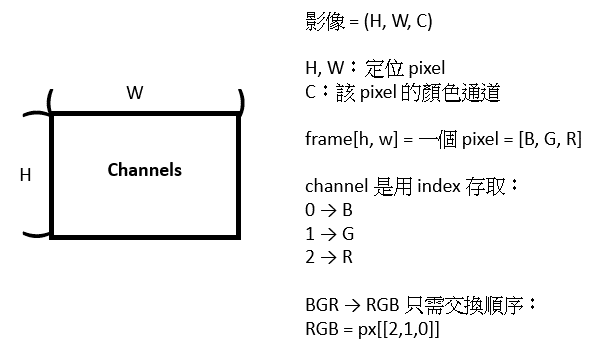

In [ ]:
import cv2
import os
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
!ls /content


sample_data


有錯誤:

1.   imshow 一定要在 while 裡面

    imshow 在 while 外面代表：
    影片讀完
    ret == False
    才顯示「最後一張 frame」
    但視窗一閃就被 destroyAllWindows() 關掉

2.   YUV 轉換根本沒在用 frame
    
    這一行寫錯
    =>newRGB = frame[2,1,0]
    這代表的是：
    第 y=2
    第 x=1
    第 channel=0 (B)
    👉 拿到的是 一個數值（int）
    ❌ 不是一個像素
    ❌ 跟目前在跑的 (h, w) 完全沒關係
    
    所以你每一個 pixel 都在用同一個藍色值做轉換
    
    本來是想做：
    frame[h, w, 2], frame[h, w, 1], frame[h, w, 0]
    
    但現在你每個 pixel 都拿 同一個像素 (2,1,0)
    而且還少了 h, w
    應改:
    B, G, R = frame[y, x]
    rgb = np.array([R, G, B])
    
3.   型別會直接爆

    原: out[h,w] = np.astype(YUV, int)
    =>np.astype 不能這樣用
    正確:out[h, w] = YUV.astype(np.uint8)

    影像要顯示 / 存檔  → uint8 (0 ~ 255)
    中間計算 / 教學示範 → int 或 float
    
    如果你用 int：
    OpenCV 不保證怎麼顯示
    有些值 < 0 或 > 255
    顏色會怪 or 直接黑畫面
4.   顏色會亂掉

    OpenCV 顯示影像 預設是 BGR
    你轉成 YUV 後直接 imshow
    OpenCV 不知道你現在是 YUV
    只能
    1.只顯示 Y（灰階）
    或2.再轉回 BGR



In [ ]:
#能執行但有幾個錯誤(上表)
cap = cv2.VideoCapture('/content/chengdu.mp4') #影像匯入

def YUV(frame:np.ndarray):  #np.ndarray 是「說明書」
  height,width=frame.shape[:2]
  A = np.array([[0.299,0.587,0.114],[-0.169,-0.331,0.5],[0.5,-0.419,-0.081]])  #權重
  bgr = np.array([255,127,0])
  out = np.zeros_like(frame, dtype=np.float32)  #有寫dtype=np.float32，在有負數值輸入時，就不會炸掉
   #建立一張新的影像，用來存「處理後的結果」
  for h in range(height):    #把所有的px轉成
    for w in range(width):
      newRGB=frame[2,1,0]       #因YUV是RGB，但CV是BGR，因此要轉
      #2,1,0是index的位置
      YUV=A @ newRGB+ [0,128,128]  #位移設[0,128,128]
      out[h,w]=np.astype(YUV,int)    #小數轉整數
  return out

if cap.isOpened():
  ret, frame = cap.read()

  YUVflag=False

  while ret:         #ret 是「上一張 frame 的結果」
    key = cv2.waitKey(1)
    if key==ord('y'): YUVflag=not YUVflag
    elif key == ord('q'): break

    if YUVflag: frame=YUV(frame)

  cv2.imshow('haha', frame)  # 顯示處理後的影像
  ret, frame = cap.read()  # 讀取下一個frame

cap.release()
cv2.destroyAllWindows()

In [1]:
#Chat GPT改版，但colab沒
import cv2
import numpy as np

cap = cv2.VideoCapture('chengdu.mp4')

def BGR2YUV(frame):
    h, w = frame.shape[:2]
    A = np.array([
        [0.299, 0.587, 0.114],
        [-0.169, -0.331, 0.5],
        [0.5, -0.419, -0.081]
    ])

    out = np.zeros_like(frame, dtype=np.float32)

    for y in range(h):
        for x in range(w):
            B, G, R = frame[y, x]
            rgb = np.array([R, G, B])
            yuv = A @ rgb + [0, 128, 128]
            out[y, x] = yuv

    return out.astype(np.uint8)

YUVflag = False

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    key = cv2.waitKey(1)
    if key == ord('y'):
        YUVflag = not YUVflag
    elif key == ord('q'):
        break

    if YUVflag:
        yuv = BGR2YUV(frame)
        cv2.imshow('haha', yuv)
    else:
        cv2.imshow('haha', frame)

cap.release()
cv2.destroyAllWindows()
